# **MÓDULO 32 - Exercício**
# Random Forest


Nesta tarefa, vocês vão trabalhar com uma base de dados de avaliações de vinhos, onde o objetivo é prever a pontuação dos vinhos usando o algoritmo de Random Forest para classificação multiclasse.

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from scipy import stats

import warnings


warnings.filterwarnings('ignore')
RND = 42 #mt importante 

In [55]:
df = pd.read_csv("winequality-red.csv", delimiter=',')

df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


**Vamos conhecer nossa base:**

Características dos Vinhos (Features)

Fixed Acidity: Acidez fixa do vinho.

Volatile Acidity: Acidez volátil do vinho.

Citric Acid: Quantidade de ácido cítrico no vinho.

Residual Sugar: Açúcar residual presente no vinho.

Chlorides: Nível de cloretos no vinho.

Free Sulfur Dioxide: Dióxido de enxofre livre no vinho.

Total Sulfur Dioxide: Quantidade total de dióxido de enxofre no vinho.

Density: Densidade do vinho.

pH: Nível de pH do vinho.

Sulphates: Quantidade de sulfatos no vinho.

Alcohol: Teor alcoólico do vinho.



**Variável de Saída (Target):**

Quality: Pontuação do vinho baseada em dados sensoriais, variando de 0 a 10.


Esta abordagem permitirá que vocês explorem como diferentes características químicas influenciam a qualidade dos vinhos e como o Random Forest pode ser usado para fazer previsões precisas com base nesses dados.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

In [56]:
# A) tipos
print('\nTipos de dados:')
print(df.dtypes)

# B) missing values
print('\nValores faltantes por coluna:')
print(df.isnull().sum())

# Comentário: se não houver valores faltantes, não aplicamos imputação. 
# Caso houvesse, justificaríamos imputação por mediana ou remoção dependendo do padrão.


Tipos de dados:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Valores faltantes por coluna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


# 2 - Realize a segunda e terceita etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.

B) Verifique o balanceamento da váriavel Target.

C)  Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.

D) Crie um novo dataframe apenas com as váriaveis que parecem ter maior correlação com a target. (Negativa ou positiva)



Número de observações com |z|>3 por coluna:
{'fixed acidity': np.int64(12), 'volatile acidity': np.int64(10), 'citric acid': np.int64(1), 'residual sugar': np.int64(30), 'chlorides': np.int64(31), 'free sulfur dioxide': np.int64(22), 'total sulfur dioxide': np.int64(15), 'density': np.int64(18), 'pH': np.int64(8), 'sulphates': np.int64(27), 'alcohol': np.int64(8), 'quality': np.int64(10)}

Distribuição da variável target (quality):
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


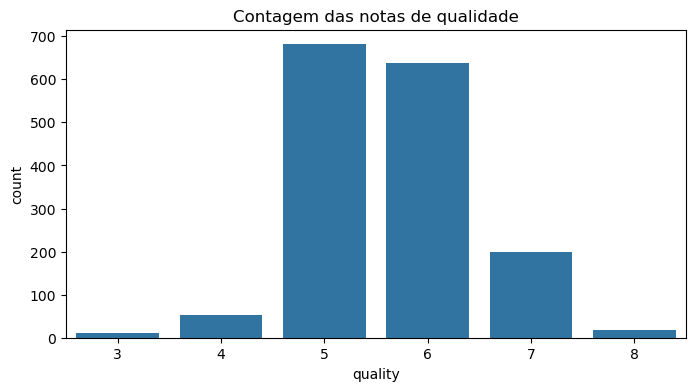

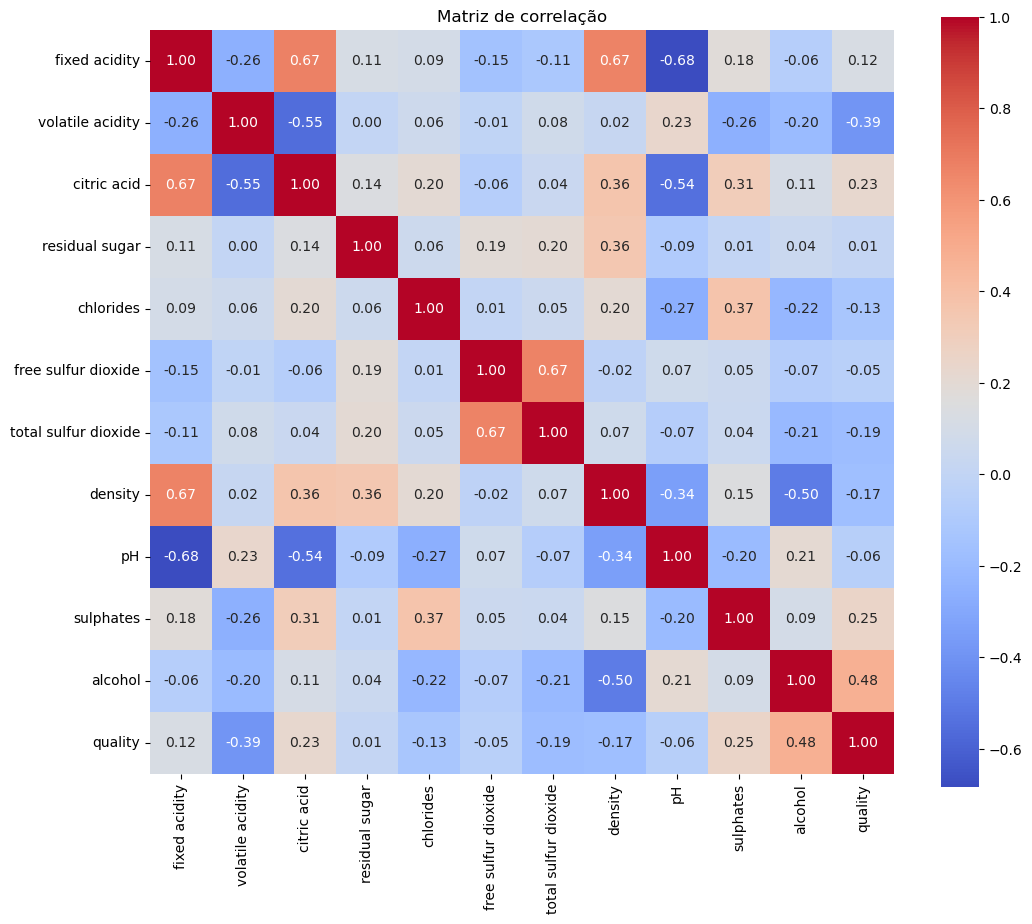


Correlação absoluta das features com quality:
quality                 1.000000
alcohol                 0.476166
volatile acidity        0.390558
sulphates               0.251397
citric acid             0.226373
total sulfur dioxide    0.185100
density                 0.174919
chlorides               0.128907
fixed acidity           0.124052
pH                      0.057731
free sulfur dioxide     0.050656
residual sugar          0.013732
Name: quality, dtype: float64

Features selecionadas (|corr| > 0.10):
['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'total sulfur dioxide', 'density', 'chlorides', 'fixed acidity']

Dimensão do novo dataframe: (1599, 9)


In [57]:
# A) describe
desc = df.describe().T
desc[['min','25%','50%','75%','max','mean','std']]

# Identificação simples de outliers com z-score para cada feature (opcional)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()


z_scores = np.abs(stats.zscore(df[numeric_cols]))
# marcar como outlier quando z > 3
outlier_flags = (z_scores > 3)
num_outliers_per_col = outlier_flags.sum(axis=0)
print('\nNúmero de observações com |z|>3 por coluna:')
print(dict(zip(numeric_cols, num_outliers_per_col)))

# B) balanceamento da target
print('\nDistribuição da variável target (quality):')
print(df['quality'].value_counts().sort_index())


plt.figure(figsize=(8,4))
sns.countplot(x='quality', data=df)
plt.title('Contagem das notas de qualidade')
plt.show()


# C) Correlações
corr = df.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Matriz de correlação')
plt.show()


# correlação direta com a target (ordenada)
corr_with_target = corr['quality'].abs().sort_values(ascending=False)
print('\nCorrelação absoluta das features com quality:')
print(corr_with_target)


# D) selecionar features com maior correlação absoluta (limiar arbitrário, por exemplo > 0.10)
threshold = 0.10
strong_features = corr_with_target[corr_with_target > threshold].index.tolist()
# remover a própria target da lista
if 'quality' in strong_features:
   strong_features.remove('quality')


print('\nFeatures selecionadas (|corr| > {:.2f}):'.format(threshold))
print(strong_features)


# Novo dataframe com as variáveis fortes
df_strong = df[strong_features + ['quality']].copy()
print('\nDimensão do novo dataframe:', df_strong.shape)

# 3 - Preparação Final dos Dados

A) Separe a base em X(Features) e Y(Target)

B) Separe a base em treino e teste.


In [58]:
#           
X = df_strong.drop('quality', axis=1)
y = df_strong['quality']


# opcional: normalizar/standardizar features numéricas (Random Forest não exige, mas faz sentido para comparação)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=RND, stratify=y)
print('Tamanho treino:', X_train.shape, 'Tamanho teste:', X_test.shape)


# verificar balanceamento no treino
print('\nDistribuição em treino:')
print(y_train.value_counts().sort_index())

Tamanho treino: (1279, 8) Tamanho teste: (320, 8)

Distribuição em treino:
quality
3      8
4     42
5    545
6    510
7    159
8     15
Name: count, dtype: int64


# 4 - Modelagem

A) Inicie e treine o modelo de Random Forest

B) Aplique a base de teste o modelo.


In [59]:
rf = RandomForestClassifier(n_estimators=200, random_state=RND, n_jobs=-1)
rf.fit(X_train, y_train)


# previsões
y_pred = rf.predict(X_test)

# 5 - Avaliação

A) Avalie as principais métricas da Claissificação e traga insights acerca do resultado, interprete os valores achados.

B) Você nota que o modelo teve dificuldade para prever alguma classe? Se sim, acredita que tenha relação com o balanceamento dos dados? Explique.


In [60]:
# extrair recalls apenas das classes numéricas (evitando 'macro avg', 'weighted avg')
recalls = {}
for k, v in report.items():
    try:
        # se v for dicionário, pega o recall
        recalls[int(k)] = v['recall']
    except (TypeError, KeyError, ValueError):
        continue

# ordenar
sorted_recalls = sorted(recalls.items(), key=lambda x: x[1])
print('\nRecall por classe (ordenado):')
for cl, r in sorted_recalls:
    print(f'Classe {cl}: recall = {r:.3f}')


Recall por classe (ordenado):
Classe 3: recall = 0.000
Classe 4: recall = 0.000
Classe 8: recall = 0.333
Classe 7: recall = 0.475
Classe 6: recall = 0.727
Classe 5: recall = 0.750



Acurácia (test): 0.6719

Classification report:
              precision    recall  f1-score   support

           3     0.0000    0.0000    0.0000         2
           4     0.0000    0.0000    0.0000        11
           5     0.7034    0.7500    0.7260       136
           6     0.6327    0.7266    0.6764       128
           7     0.7308    0.4750    0.5758        40
           8     0.5000    0.3333    0.4000         3

    accuracy                         0.6719       320
   macro avg     0.4278    0.3808    0.3963       320
weighted avg     0.6481    0.6719    0.6548       320



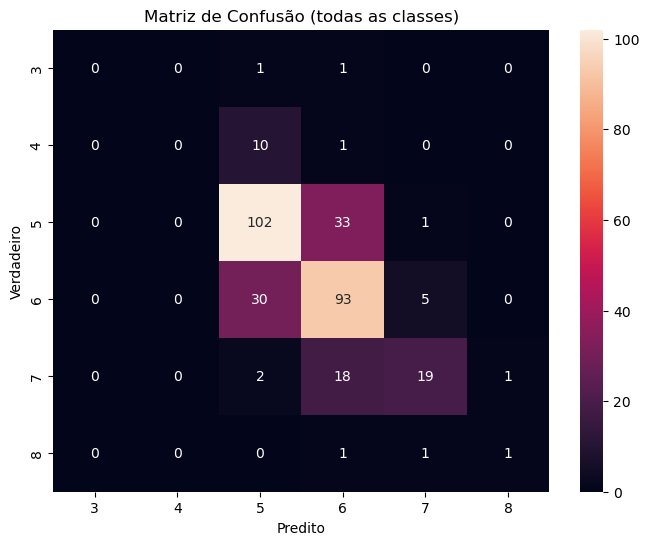


Insights iniciais:
- A acurácia dá uma visão geral da performance, mas em problemas multiclasse desbalanceados é importante olhar para precisão/recall por classe.
- Classes com poucas observações geralmente apresentam recall baixo e são mais frequentemente confundidas com classes próximas (ex: 5 vs 6).

Recall por classe (ordenado):
Classe 3: recall = 0.000
Classe 4: recall = 0.000
Classe 8: recall = 0.333
Classe 7: recall = 0.475
Classe 6: recall = 0.727
Classe 5: recall = 0.750

Comparando com frequência original da base:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [61]:
# Acurácia
acc = accuracy_score(y_test, y_pred)
print('\nAcurácia (test): {:.4f}'.format(acc))

# Classification report completo
print('\nClassification report:')
print(classification_report(y_test, y_pred, digits=4))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão (todas as classes)')
plt.show()

# Insights iniciais
print('\nInsights iniciais:')
print('- A acurácia dá uma visão geral da performance, mas em problemas multiclasse desbalanceados é importante olhar para precisão/recall por classe.')
print('- Classes com poucas observações geralmente apresentam recall baixo e são mais frequentemente confundidas com classes próximas (ex: 5 vs 6).')

# Identificar classes com pior recall (ajustado para evitar TypeError) n sei se e recomendado!!
report = classification_report(y_test, y_pred, output_dict=True)

recalls = {}
for k, v in report.items():
    try:
        # se v for um dicionário, pega o recall
        recalls[int(k)] = v['recall']
    except (TypeError, KeyError, ValueError):
        continue

sorted_recalls = sorted(recalls.items(), key=lambda x: x[1])
print('\nRecall por classe (ordenado):')
for cl, r in sorted_recalls:
    print(f'Classe {cl}: recall = {r:.3f}')

# Comparando com frequência original da base
print('\nComparando com frequência original da base:')
print(df['quality'].value_counts().sort_index())

# 5 - Melhorando os Hyperparametros

A) Defina o Grid de parametros que você quer testar

B) Inicie e Treine um novo modelo utilizando o random search.

C) Avalie os resultados do modelo.

D) Você identificou melhorias no modelo após aplicar o random search? Justifique.


ps. Essa parte da atividade demorará um pouco para rodar!

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Melhores parâmetros encontrados:
{'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Melhor score (cv): 0.6732

Acurácia com melhor estimator (test): 0.6719

Classification report (melhor modelo):
              precision    recall  f1-score   support

           3     0.0000    0.0000    0.0000         2
           4     0.0000    0.0000    0.0000        11
           5     0.7214    0.7426    0.7319       136
           6     0.6194    0.7500    0.6784       128
           7     0.7200    0.4500    0.5538        40
           8     0.0000    0.0000    0.0000         3

    accuracy                         0.6719       320
   macro avg     0.3435    0.3238    0.3274       320
weighted avg     0.6443    0.6719    0.6517       320



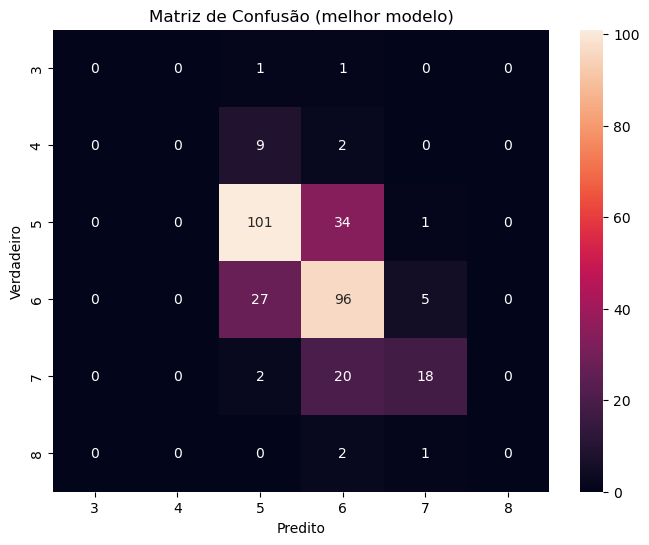


Comparação:
Acurácia antes: 0.6719, depois RandomizedSearch: 0.6719


In [ ]:
# %%
param_dist = {
'n_estimators': [100, 200, 300, 400],
'max_depth': [None, 5, 10, 20, 30],
'min_samples_split': [2, 5, 10],
'min_samples_leaf': [1, 2, 4],
'max_features': ['auto', 'sqrt', 'log2']
}


rf_base = RandomForestClassifier(random_state=RND)
rs = RandomizedSearchCV(rf_base, param_distributions=param_dist, n_iter=20, cv=3, scoring='accuracy', random_state=RND, n_jobs=-1, verbose=1)
rs.fit(X_train, y_train)


print('\nMelhores parâmetros encontrados:')
print(rs.best_params_)
print('Melhor score (cv): {:.4f}'.format(rs.best_score_))


# avaliar melhor modelo na base de teste
best_rf = rs.best_estimator_
y_pred_best = best_rf.predict(X_test)
acc_best = accuracy_score(y_test, y_pred_best)
print('\nAcurácia com melhor estimator (test): {:.4f}'.format(acc_best))
print('\nClassification report (melhor modelo):')
print(classification_report(y_test, y_pred_best, digits=4))


cm_best = confusion_matrix(y_test, y_pred_best, labels=sorted(y.unique()))
plt.figure(figsize=(8,6))
sns.heatmap(cm_best, annot=True, fmt='d', xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão (melhor modelo)')
plt.show()


# comparar melhorias
print('\nComparação:')
print('Acurácia antes: {:.4f}, depois RandomizedSearch: {:.4f}'.format(acc, acc_best))

# 6 - Chegando a perfeição

Baseado em tudo que você já aprendeu até agora, quais outras técnicas você acredita que poderiam ser aplicadas ao modelo para melhorar ainda mais suas previsões?

In [63]:
# # 7 - Observações finais e sugestões para melhorar o modelo
#
# - Reamostrar (oversampling com SMOTE) para balancear classes raras.
# - Testar técnicas de ensemble diferentes (GradientBoosting, XGBoost, LightGBM).
# - Ajuste fino dos thresholds ou transformar o problema em regressão discretizada e utilizar modelos de regressão.
# - Fazer engenharia de features: criar interações, polinômios, ou extrair componentes via PCA.
# - Testar validação estratificada com mais folds e executar mais iterações no RandomizedSearch ou um GridSearch mais focado.
# - Analisar feature importance e reduzir dimensionalidade se necessário.


print('\nSugestões para próximos passos:')
print('- Aplicar SMOTE para classes com pouca representação e re-treinar.')
print('- Experimentar XGBoost/LightGBM (muitas vezes melhoram resultado em tabular).')
print('- Fazer análise de features importantes e tentar reduzir ruído.')


Sugestões para próximos passos:
- Aplicar SMOTE para classes com pouca representação e re-treinar.
- Experimentar XGBoost/LightGBM (muitas vezes melhoram resultado em tabular).
- Fazer análise de features importantes e tentar reduzir ruído.
